# 04 Disk-integrated intensity mapping: single image and stack mode

这个 notebook 承接 `01_Findatom.ipynb` 保存的原子柱坐标、分类、精修和 curation 结果，支持单张 2D 图像和 3D stack 的固定半径圆盘积分强度分析。

Stack mode 假设所有 slices 已经配准到同一个坐标系；本 notebook 不做 stack registration 或 drift correction。`fixed` mode 在每个 slice 测量同一空间坐标，`slice_refined` mode 在每个 slice 附近复用 Notebook01 refinement 后测量局部拟合中心。

`slice_refined` 对弱柱或 vacancy-like columns 可能偏向邻近亮峰；解释 profiles 前必须检查 `center_shift_px`、`center_shift_rejected`、`quality_score` 和 `refinement_path`。强度差异不能在没有校准和 controls 的情况下直接解释为 composition 或 vacancy concentration。

边界说明：这里不做自动 vacancy threshold、不做背景扣除、不做 stack registration、不修改 detection/classification/curation/strain/vPCF/GPA/HZO polarization workflow。

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'src' / 'em_atom_workbench').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
PROJECT_SRC = str(PROJECT_ROOT / 'src')
if PROJECT_SRC in sys.path:
    sys.path.remove(PROJECT_SRC)
sys.path.insert(0, PROJECT_SRC)
for module_name in list(sys.modules):
    if module_name == 'em_atom_workbench' or module_name.startswith('em_atom_workbench.'):
        del sys.modules[module_name]

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from em_atom_workbench import (
    AnalysisROI,
    RefinementConfig,
    compute_disk_intensity_table,
    compute_per_slice_disk_intensity_table,
    compute_stack_disk_intensity_table,
    export_disk_intensity_analysis,
    export_notebook04_intensity_results,
    initialize_analysis_workspace,
    initialize_disk_intensity_analysis,
    initialize_notebook04_intensity_context,
    launch_stack_refinement_napari_viewer,
    plot_disk_intensity_histogram,
    plot_disk_intensity_map,
    plot_stack_intensity_histogram,
    plot_stack_intensity_profiles,
    plot_stack_refinement_shift_profile,
    plot_stack_slice_intensity_map,
    run_notebook04_intensity_analysis,
    summarize_stack_disk_intensity,
)

plt.rcParams['figure.dpi'] = 140
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans', 'Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 0. Workspace parameters

这一格只定义当前 dataset/run 的统一 workspace。04 默认从 `workspace/state/sessions/01_final_curated.pkl` 读取 01 的最终 curated session，并把所有 04 输出写入 canonical `04_intensity_mapping/`。

In [2]:
OUTPUT_ROOT = PROJECT_ROOT / 'results'
DATASET_ID = '2'
ANALYSIS_ID = 'fix'

workspace = initialize_analysis_workspace(
    output_root=OUTPUT_ROOT,
    dataset_id=DATASET_ID,
    analysis_id=ANALYSIS_ID,
)

RESULT_ROOT = workspace.root

print(f'workspace: {workspace.root}')
print(f'04 output: {workspace.root / "04_intensity_mapping"}')

workspace: d:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Python\atom_analysis_manual\results\2\fix
04 output: d:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Python\atom_analysis_manual\results\2\fix\04_intensity_mapping


## 1. Session and coordinate parameters

读取优先级固定为：`SESSION_PATH > USE_ACTIVE_SESSION > SESSION_SOURCE`。坐标源可选 `candidate`、`refined` 或 `curated`。

In [4]:
SESSION_SOURCE = '01_final_curated'
SESSION_PATH = None
USE_ACTIVE_SESSION = False

COORDINATE_SOURCE = 'refined'  # 'candidate', 'refined', or 'curated'
USE_KEEP_ONLY = True
TARGET_CLASS_IDS = None
TARGET_CLASS_NAMES = None
ROIS = None

## 2. Input mode parameters

Stack slices 必须已经和 Notebook01 坐标系对齐。本 notebook 不估计或校正 slice drift。

In [5]:
INTENSITY_INPUT_MODE = 'stack'  # 'single_image' or 'stack'

# Single-image mode
IMAGE_CHANNEL = None
IMAGE_KEY = 'raw'

# Stack mode
STACK_PATH = "D:/LIANGKUAN/PolyU-PhD/Reserch/HfO2/Ptycho/17_45.dm4"
STACK_AXIS = 0
STACK_SLICE_INDICES = None
STACK_PREVIEW_SLICE = 0
COORDINATE_X_OFFSET_PX = 0.0
COORDINATE_Y_OFFSET_PX = 0.0

## 3. Coordinate mode parameters

`fixed` mode 测量每个 slice 上同一组 x/y 坐标；`slice_refined` mode 把同一组 seed 坐标放到每个 slice 上，并复用 Notebook01 refinement 逻辑。使用 `slice_refined` 时通常保留 fixed-coordinate control。

In [6]:
STACK_COORDINATE_MODE = 'slice_refined'  # 'fixed' or 'slice_refined'
COMPUTE_FIXED_COORDINATE_CONTROL = True

## 4. Disk integration parameters

In [7]:
DISK_RADIUS_PX = 2.0

## 5. Notebook01-equivalent refinement parameters

这些参数用于 stack `slice_refined` mode。弱柱、缺陷或低信噪点可能触发 shift guard 或 fallback，解释前要查看 QC 表。

In [8]:
REFINEMENT_CONFIG = RefinementConfig(
    mode='adaptive_atomap',
    fit_half_window=6,
    com_half_window=4,
    nn_radius_fraction=0.38,
    min_patch_radius_px=5,
    max_patch_radius_px=14,
    initial_sigma_px=1.2,
    min_sigma_px=0.5,
    max_sigma_px=4.0,
    max_center_shift_px=3.0,
    max_nfev=4000,
    gaussian_retry_count=3,
    gaussian_retry_shrink_factor=0.9,
    sigma_ratio_limit=4.0,
    fit_edge_margin_px=1.0,
    gaussian_image_source='raw',
    fallback_to_quadratic=True,
    fallback_to_com=True,
    quality_floor=0.0,
    overlap_trigger_px=None,
)

NN_CONTEXT_MODE = 'all'

CLASS_REFINEMENT_OVERRIDES = {
    # 0: dict(max_sigma_px=3.0, max_center_shift_px=1.5),
    # 1: dict(fit_half_window=4, fallback_to_com=False),
    # -1: dict(gaussian_image_source='processed'),
}

## 6. Plot parameters

In [9]:
MAP_METRIC = 'disk_intensity_sum'
STACK_PROFILE_METRIC = 'disk_intensity_mean'
STACK_PROFILE_STAT = 'mean'
STACK_PROFILE_ERROR = 'std'
STACK_PROFILE_GROUP_BY = 'class_name'
STACK_MAP_SLICE_INDEX = 0
STACK_HIST_SLICE_INDEX = None
HIST_BINS = 30

## 7. Napari review parameters

Napari 只在 `OPEN_STACK_REFINEMENT_VIEWER=True` 时 lazy import；没有安装 napari 不影响计算和导出。

In [10]:
OPEN_STACK_REFINEMENT_VIEWER = True
NAPARI_REVIEW_SLICE_INDEX = 0
NAPARI_POINT_SIZE = 5.0
SHOW_SEED_POINTS_IN_NAPARI = True

## 8. Export parameters

In [11]:
SAVE_PREVIEW_FIGURES = False
SAVE_FINAL_FIGURES = True
FIGURE_FORMATS = ('png', 'pdf')
FIGURE_DPI = 600
FIGURE_SPECS = {
    '04A_single_image_intensity_map': {'save': True, 'formats': FIGURE_FORMATS, 'dpi': FIGURE_DPI},
    '04B_single_image_intensity_histogram': {'save': True, 'formats': FIGURE_FORMATS, 'dpi': FIGURE_DPI},
    '04C_stack_slice_intensity_map': {'save': True, 'formats': FIGURE_FORMATS, 'dpi': FIGURE_DPI},
    '04D_stack_intensity_profiles': {'save': True, 'formats': FIGURE_FORMATS, 'dpi': FIGURE_DPI},
    '04E_stack_intensity_histogram': {'save': True, 'formats': FIGURE_FORMATS, 'dpi': FIGURE_DPI},
    '04F_stack_refinement_shift_profile': {'save': True, 'formats': FIGURE_FORMATS, 'dpi': FIGURE_DPI},
}

## 9. Initialize analysis context

In [12]:
context = initialize_notebook04_intensity_context(
    workspace=workspace,
    result_root=RESULT_ROOT,
    session_path=SESSION_PATH,
    session_source=SESSION_SOURCE,
    use_active_session=USE_ACTIVE_SESSION,
    coordinate_source=COORDINATE_SOURCE,
    use_keep_only=USE_KEEP_ONLY,
    class_filter=TARGET_CLASS_NAMES,
    class_id_filter=TARGET_CLASS_IDS,
    rois=ROIS,
    intensity_input_mode=INTENSITY_INPUT_MODE,
    image_channel=IMAGE_CHANNEL,
    image_key=IMAGE_KEY,
    stack_path=STACK_PATH,
    stack_axis=STACK_AXIS,
    stack_slice_indices=STACK_SLICE_INDICES,
    stack_preview_slice=STACK_PREVIEW_SLICE,
)

for name, table in context['summary_tables'].items():
    print(name)
    display(table)

notebook04_intensity_setup_summary


,field,value
0,session_name,2
1,current_stage,curated
2,session_load_mode,stage_session
3,resolved_session_path,d:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Pytho...
4,intensity_input_mode,stack
5,coordinate_source,refined
6,source_table,refined_points
7,image_channel,Ptycho_DW1
8,image_key,raw
9,stack_path,D:/LIANGKUAN/PolyU-PhD/Reserch/HfO2/Ptycho/17_...


points_preview


,point_id,atom_id,x_px,y_px,x_nm,y_nm,class_id,class_name,class_color,roi_id,roi_name,roi_color,scope_id,keep,coordinate_source,source_table,source_type,point_set
0,atom:1986,1986,616.992712,101.962087,9.579346,1.583050,0,class_0,#00a5cf,global,global,#ff9f1c,global:atoms:refined_points,True,refined,refined_points,atom,atoms
1,atom:2479,2479,612.745171,105.996596,9.513399,1.645689,0,class_0,#00a5cf,global,global,#ff9f1c,global:atoms:refined_points,True,refined,refined_points,atom,atoms
2,atom:2005,2005,663.826353,101.242273,10.306479,1.571874,0,class_0,#00a5cf,global,global,#ff9f1c,global:atoms:refined_points,True,refined,refined_points,atom,atoms
3,atom:2742,2742,660.596418,105.157796,10.256331,1.632666,0,class_0,#00a5cf,global,global,#ff9f1c,global:atoms:refined_points,True,refined,refined_points,atom,atoms
4,atom:2073,2073,77.916986,527.976228,1.209729,8.197288,0,class_0,#00a5cf,global,global,#ff9f1c,global:atoms:refined_points,True,refined,refined_points,atom,atoms


## 10. Run analysis

In [13]:
analysis_result = run_notebook04_intensity_analysis(
    context,
    intensity_input_mode=INTENSITY_INPUT_MODE,
    stack_coordinate_mode=STACK_COORDINATE_MODE,
    compute_fixed_coordinate_control=COMPUTE_FIXED_COORDINATE_CONTROL,
    disk_radius_px=DISK_RADIUS_PX,
    refinement_config=REFINEMENT_CONFIG,
    class_refinement_overrides=CLASS_REFINEMENT_OVERRIDES,
    nn_context_mode=NN_CONTEXT_MODE,
    x_offset_px=COORDINATE_X_OFFSET_PX,
    y_offset_px=COORDINATE_Y_OFFSET_PX,
    stack_profile_metric=STACK_PROFILE_METRIC,
)

tables = analysis_result['tables']
print('available tables:', sorted(tables))
for name, table in tables.items():
    print(name, table.shape)
    display(table.head())

available tables: ['stack_fixed_disk_intensity_summary', 'stack_fixed_disk_intensity_table', 'stack_refined_disk_intensity_summary', 'stack_refined_disk_intensity_table', 'stack_refined_points']
stack_refined_points (99960, 48)


,point_id,atom_id,candidate_id,original_candidate_id,slice_index,slice_label,x_seed_px,y_seed_px,x_px,y_px,...,gaussian_attempt_count,gaussian_image_source,refinement_path,refinement_config_source,nn_context_mode,coordinate_mode,refinement_class_id,x_phys,y_phys,unit
0,atom:1986,1986,0,0,0,0,616.992712,101.962087,616.992712,101.962087,...,1,raw,adaptive_atomap,default,all,slice_refined,0,9.830087,1.624486,nm
1,atom:2479,2479,1,1,0,0,612.745171,105.996596,612.745171,105.996596,...,1,raw,adaptive_atomap,default,all,slice_refined,0,9.762414,1.688765,nm
2,atom:2005,2005,2,2,0,0,663.826353,101.242273,663.826353,101.242273,...,1,raw,adaptive_atomap,default,all,slice_refined,0,10.576253,1.613018,nm
3,atom:2742,2742,3,3,0,0,660.596418,105.157796,660.596418,105.157796,...,1,raw,adaptive_atomap,default,all,slice_refined,0,10.524793,1.675401,nm
4,atom:2073,2073,4,4,0,0,77.916986,527.976228,77.916986,527.976228,...,1,raw,adaptive_atomap,default,all,slice_refined,0,1.241394,8.411854,nm


stack_refined_disk_intensity_table (99960, 59)


,point_id,atom_id,x_px,y_px,x_nm,y_nm,class_id,class_name,class_color,roi_id,...,candidate_id,original_candidate_id,nn_distance_px,adaptive_half_window_px,gaussian_attempt_count,gaussian_image_source,refinement_class_id,x_phys,y_phys,unit
0,atom:1986,1986,616.992712,101.962087,<NA>,<NA>,0,class_0,#00a5cf,global,...,0,0,5.858231,5,1,raw,0,9.830087,1.624486,nm
1,atom:2479,2479,612.745171,105.996596,<NA>,<NA>,0,class_0,#00a5cf,global,...,1,1,5.858231,5,1,raw,0,9.762414,1.688765,nm
2,atom:2005,2005,663.826353,101.242273,<NA>,<NA>,0,class_0,#00a5cf,global,...,2,2,5.075805,5,1,raw,0,10.576253,1.613018,nm
3,atom:2742,2742,660.596418,105.157796,<NA>,<NA>,0,class_0,#00a5cf,global,...,3,3,5.075805,5,1,raw,0,10.524793,1.675401,nm
4,atom:2073,2073,77.916986,527.976228,<NA>,<NA>,0,class_0,#00a5cf,global,...,4,4,5.639191,5,1,raw,0,1.241394,8.411854,nm


stack_refined_disk_intensity_summary (84, 15)


,slice_index,slice_label,class_id,class_name,channel_name,metric,count,mean,std,sem,median,q25,q75,min,max
0,0,0,0,class_0,Ptycho_DW1,disk_intensity_mean,1316,21443.069586,1096.599051,30.228731,21424.428571,20737.454545,22166.840909,16443.461538,25583.857143
1,0,0,1,class_1,Ptycho_DW1,disk_intensity_mean,798,28067.736360,1678.460846,59.416870,28279.019231,27263.835227,29158.515734,19820.846154,32870.642857
2,0,0,2,class_2,Ptycho_DW1,disk_intensity_mean,1456,41998.644735,2418.963576,63.394071,42118.863636,40532.303571,43638.699405,31902.615385,48695.363636
3,1,1,0,class_0,Ptycho_DW1,disk_intensity_mean,1316,21633.977602,1137.438288,31.354501,21660.716783,20880.307692,22403.562500,16874.076923,25342.000000
4,1,1,1,class_1,Ptycho_DW1,disk_intensity_mean,798,28602.706705,1797.919892,63.645674,28893.142857,27824.417582,29768.176136,21088.928571,33302.076923


stack_fixed_disk_intensity_table (99960, 30)


,point_id,atom_id,x_px,y_px,x_nm,y_nm,class_id,class_name,class_color,roi_id,...,disk_radius_px,n_pixels,disk_intensity_sum,disk_intensity_mean,is_edge,status,coordinate_mode,keep,source_type,point_set
0,atom:1986,1986,616.992712,101.962087,9.579346,1.583050,0,class_0,#00a5cf,global,...,2.0,11,245419.0,22310.818182,False,ok,fixed,True,atom,atoms
1,atom:2479,2479,612.745171,105.996596,9.513399,1.645689,0,class_0,#00a5cf,global,...,2.0,10,216713.0,21671.300000,False,ok,fixed,True,atom,atoms
2,atom:2005,2005,663.826353,101.242273,10.306479,1.571874,0,class_0,#00a5cf,global,...,2.0,13,275532.0,21194.769231,False,ok,fixed,True,atom,atoms
3,atom:2742,2742,660.596418,105.157796,10.256331,1.632666,0,class_0,#00a5cf,global,...,2.0,14,285805.0,20414.642857,False,ok,fixed,True,atom,atoms
4,atom:2073,2073,77.916986,527.976228,1.209729,8.197288,0,class_0,#00a5cf,global,...,2.0,11,228050.0,20731.818182,False,ok,fixed,True,atom,atoms


stack_fixed_disk_intensity_summary (84, 15)


,slice_index,slice_label,class_id,class_name,channel_name,metric,count,mean,std,sem,median,q25,q75,min,max
0,0,0,0,class_0,Ptycho_DW1,disk_intensity_mean,1316,21375.190039,1026.755083,28.303420,21375.208333,20730.409091,22064.514423,16443.461538,25093.384615
1,0,0,1,class_1,Ptycho_DW1,disk_intensity_mean,798,26840.258230,1733.001973,61.347605,27009.333333,25838.583333,28012.583333,19820.846154,33421.916667
2,0,0,2,class_2,Ptycho_DW1,disk_intensity_mean,1456,40135.562932,2776.128596,72.754338,40403.746795,38346.690705,42149.197115,30258.846154,48287.818182
3,1,1,0,class_0,Ptycho_DW1,disk_intensity_mean,1316,21563.438708,1056.616244,29.126570,21603.120879,20873.886364,22278.136364,16874.076923,24457.692308
4,1,1,1,class_1,Ptycho_DW1,disk_intensity_mean,798,27483.108961,1810.137325,64.078167,27733.961538,26508.001603,28744.770979,20734.181818,33558.583333


## 11. QC

In [14]:
print('available table names:', sorted(tables))
if 'stack_refined_points' in tables:
    display(tables['stack_refined_points'].head())
    if 'center_shift_rejected' in tables['stack_refined_points']:
        display(tables['stack_refined_points']['center_shift_rejected'].value_counts(dropna=False).rename_axis('center_shift_rejected').reset_index(name='count'))
    if 'refinement_path' in tables['stack_refined_points']:
        display(tables['stack_refined_points']['refinement_path'].value_counts(dropna=False).rename_axis('refinement_path').reset_index(name='count'))
for optional_table_name in (
    'stack_refined_points',
    'stack_refined_disk_intensity_table',
    'stack_refined_disk_intensity_summary',
    'stack_fixed_disk_intensity_table',
    'stack_fixed_disk_intensity_summary',
):
    if optional_table_name in tables:
        print(optional_table_name, tables[optional_table_name].shape)
for name, table in analysis_result['qc_summary_tables'].items():
    print(name)
    display(table.head())

available table names: ['stack_fixed_disk_intensity_summary', 'stack_fixed_disk_intensity_table', 'stack_refined_disk_intensity_summary', 'stack_refined_disk_intensity_table', 'stack_refined_points']


,point_id,atom_id,candidate_id,original_candidate_id,slice_index,slice_label,x_seed_px,y_seed_px,x_px,y_px,...,gaussian_attempt_count,gaussian_image_source,refinement_path,refinement_config_source,nn_context_mode,coordinate_mode,refinement_class_id,x_phys,y_phys,unit
0,atom:1986,1986,0,0,0,0,616.992712,101.962087,616.992712,101.962087,...,1,raw,adaptive_atomap,default,all,slice_refined,0,9.830087,1.624486,nm
1,atom:2479,2479,1,1,0,0,612.745171,105.996596,612.745171,105.996596,...,1,raw,adaptive_atomap,default,all,slice_refined,0,9.762414,1.688765,nm
2,atom:2005,2005,2,2,0,0,663.826353,101.242273,663.826353,101.242273,...,1,raw,adaptive_atomap,default,all,slice_refined,0,10.576253,1.613018,nm
3,atom:2742,2742,3,3,0,0,660.596418,105.157796,660.596418,105.157796,...,1,raw,adaptive_atomap,default,all,slice_refined,0,10.524793,1.675401,nm
4,atom:2073,2073,4,4,0,0,77.916986,527.976228,77.916986,527.976228,...,1,raw,adaptive_atomap,default,all,slice_refined,0,1.241394,8.411854,nm


,center_shift_rejected,count
0,False,70999
1,True,28961


,refinement_path,count
0,adaptive_atomap,84988
1,quadratic_fallback,14972


stack_refined_points (99960, 48)
stack_refined_disk_intensity_table (99960, 59)
stack_refined_disk_intensity_summary (84, 15)
stack_fixed_disk_intensity_table (99960, 30)
stack_fixed_disk_intensity_summary (84, 15)
stack_refined_disk_intensity_summary


,slice_index,slice_label,class_id,class_name,channel_name,metric,count,mean,std,sem,median,q25,q75,min,max
0,0,0,0,class_0,Ptycho_DW1,disk_intensity_mean,1316,21443.069586,1096.599051,30.228731,21424.428571,20737.454545,22166.840909,16443.461538,25583.857143
1,0,0,1,class_1,Ptycho_DW1,disk_intensity_mean,798,28067.736360,1678.460846,59.416870,28279.019231,27263.835227,29158.515734,19820.846154,32870.642857
2,0,0,2,class_2,Ptycho_DW1,disk_intensity_mean,1456,41998.644735,2418.963576,63.394071,42118.863636,40532.303571,43638.699405,31902.615385,48695.363636
3,1,1,0,class_0,Ptycho_DW1,disk_intensity_mean,1316,21633.977602,1137.438288,31.354501,21660.716783,20880.307692,22403.562500,16874.076923,25342.000000
4,1,1,1,class_1,Ptycho_DW1,disk_intensity_mean,798,28602.706705,1797.919892,63.645674,28893.142857,27824.417582,29768.176136,21088.928571,33302.076923


stack_refinement_shift_by_slice


,slice_index,count,median,mean,max
0,0,3570,0.737637,0.723999,2.997212
1,1,3570,0.676641,0.680493,2.987222
2,2,3570,0.585924,0.618829,2.991245
3,3,3570,0.498833,0.559018,2.967214
4,4,3570,0.429199,0.508018,2.997393


stack_fixed_disk_intensity_summary


,slice_index,slice_label,class_id,class_name,channel_name,metric,count,mean,std,sem,median,q25,q75,min,max
0,0,0,0,class_0,Ptycho_DW1,disk_intensity_mean,1316,21375.190039,1026.755083,28.303420,21375.208333,20730.409091,22064.514423,16443.461538,25093.384615
1,0,0,1,class_1,Ptycho_DW1,disk_intensity_mean,798,26840.258230,1733.001973,61.347605,27009.333333,25838.583333,28012.583333,19820.846154,33421.916667
2,0,0,2,class_2,Ptycho_DW1,disk_intensity_mean,1456,40135.562932,2776.128596,72.754338,40403.746795,38346.690705,42149.197115,30258.846154,48287.818182
3,1,1,0,class_0,Ptycho_DW1,disk_intensity_mean,1316,21563.438708,1056.616244,29.126570,21603.120879,20873.886364,22278.136364,16874.076923,24457.692308
4,1,1,1,class_1,Ptycho_DW1,disk_intensity_mean,798,27483.108961,1810.137325,64.078167,27733.961538,26508.001603,28744.770979,20734.181818,33558.583333


## 12. Napari viewer

In [15]:
if OPEN_STACK_REFINEMENT_VIEWER and INTENSITY_INPUT_MODE == 'stack' and STACK_COORDINATE_MODE == 'slice_refined':
    viewer = launch_stack_refinement_napari_viewer(
        stack=context['stack'],
        refined_points=tables['stack_refined_points'],
        seed_points=context['points'],
        intensity_table=tables.get('stack_refined_disk_intensity_table'),
        slice_index=NAPARI_REVIEW_SLICE_INDEX,
        point_size=NAPARI_POINT_SIZE,
        show_seed_points=SHOW_SEED_POINTS_IN_NAPARI,
        show_refined_points=True,
    )
    viewer.show(block=True)

TypeError: add_points() got an unexpected keyword argument 'edge_color'

## 13. Plot results

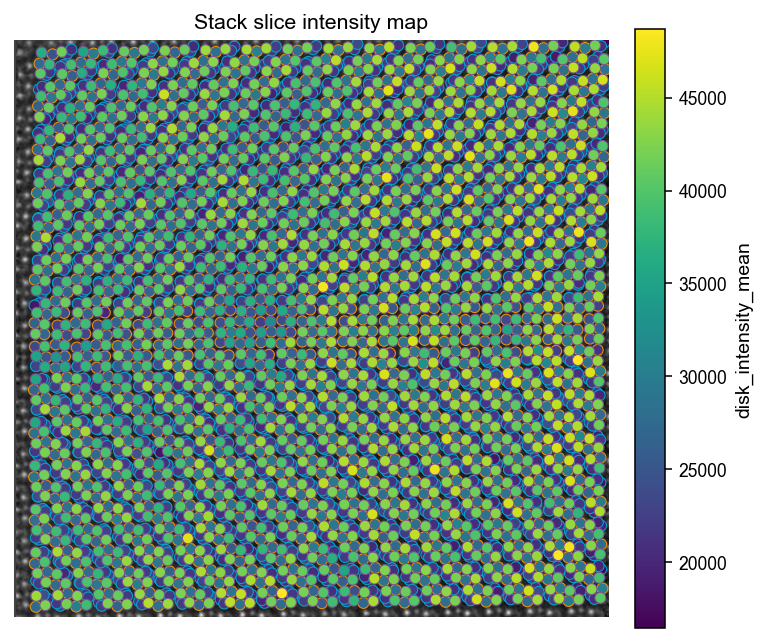

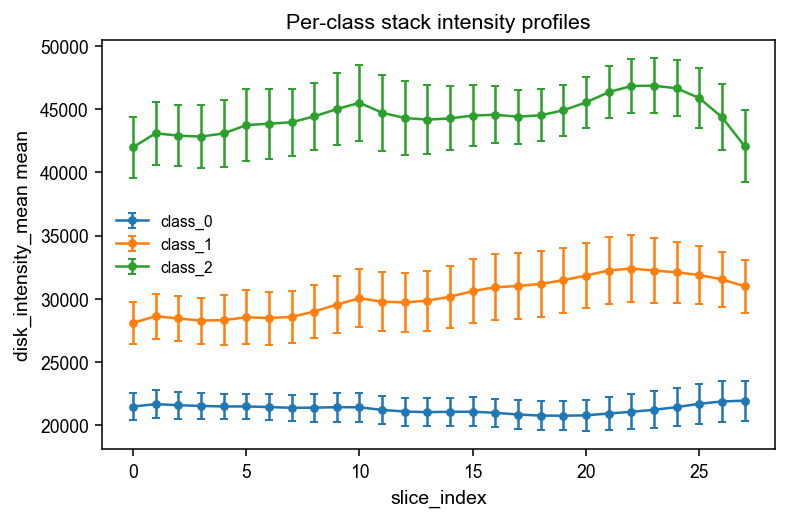

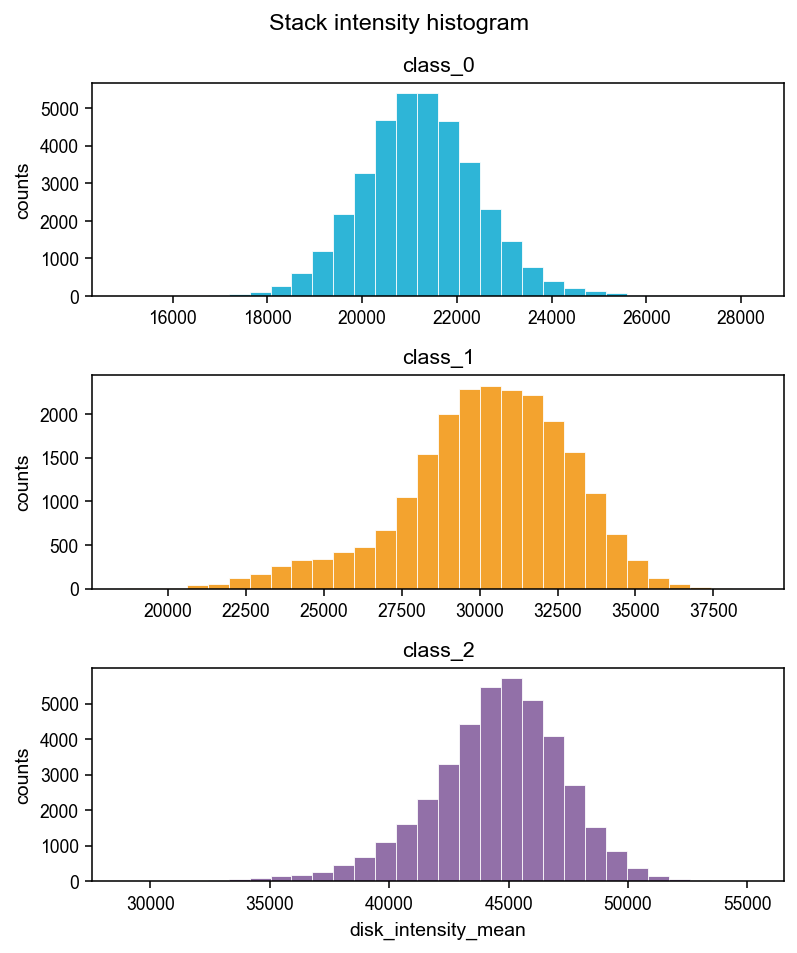

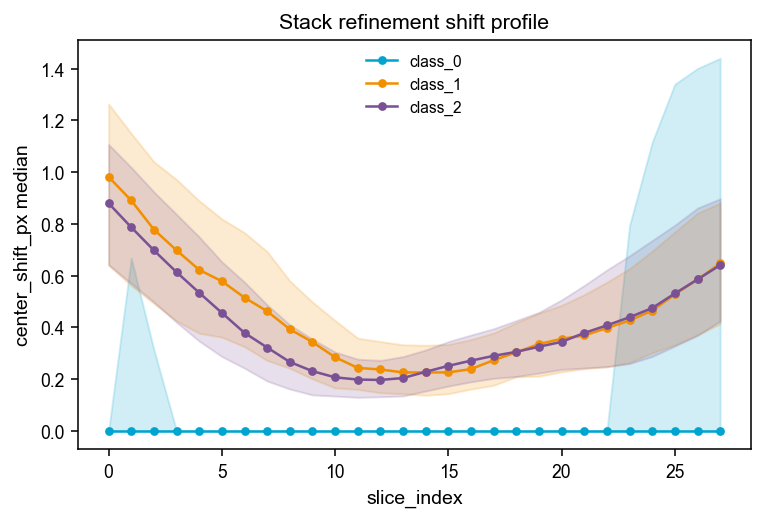

In [16]:
preview_figures = {}
final_figures = {}

if INTENSITY_INPUT_MODE == 'single_image':
    fig, ax = plot_disk_intensity_map(context['image'], tables['disk_intensity_table'], metric=MAP_METRIC, title='Disk-integrated intensity map')[0:2]
    final_figures['04A_single_image_intensity_map'] = fig
    display(fig)
    plt.close(fig)

    fig, axes = plot_disk_intensity_histogram(tables['disk_intensity_table'], metric=MAP_METRIC, bins=HIST_BINS, title='Disk-integrated intensity histogram')
    final_figures['04B_single_image_intensity_histogram'] = fig
    display(fig)
    plt.close(fig)

if INTENSITY_INPUT_MODE == 'stack':
    stack_table_key = 'stack_refined_disk_intensity_table' if 'stack_refined_disk_intensity_table' in tables else 'stack_disk_intensity_table'
    stack_summary_key = 'stack_refined_disk_intensity_summary' if 'stack_refined_disk_intensity_summary' in tables else 'stack_disk_intensity_summary'

    fig, ax = plot_stack_slice_intensity_map(context['stack'], tables[stack_table_key], slice_index=STACK_MAP_SLICE_INDEX, metric=STACK_PROFILE_METRIC, title='Stack slice intensity map')
    final_figures['04C_stack_slice_intensity_map'] = fig
    display(fig)
    plt.close(fig)

    fig, ax = plot_stack_intensity_profiles(tables[stack_summary_key], metric=STACK_PROFILE_METRIC, group_by=STACK_PROFILE_GROUP_BY, stat=STACK_PROFILE_STAT, error=STACK_PROFILE_ERROR, title='Per-class stack intensity profiles')
    final_figures['04D_stack_intensity_profiles'] = fig
    display(fig)
    plt.close(fig)

    fig, axes = plot_stack_intensity_histogram(tables[stack_table_key], metric=STACK_PROFILE_METRIC, slice_index=STACK_HIST_SLICE_INDEX, bins=HIST_BINS, title='Stack intensity histogram')
    final_figures['04E_stack_intensity_histogram'] = fig
    display(fig)
    plt.close(fig)

if INTENSITY_INPUT_MODE == 'stack' and 'stack_refined_points' in tables:
    fig, ax = plot_stack_refinement_shift_profile(tables['stack_refined_points'], group_by=STACK_PROFILE_GROUP_BY, title='Stack refinement shift profile')
    final_figures['04F_stack_refinement_shift_profile'] = fig
    display(fig)
    plt.close(fig)

## 14. Export results

导出 CSV、figures、config、manifest 和 04 stage session。

In [ ]:
notebook04_export_config = {
    'dataset_id': DATASET_ID,
    'analysis_id': ANALYSIS_ID,
    'session_source': SESSION_SOURCE,
    'session_path': None if SESSION_PATH is None else str(SESSION_PATH),
    'use_active_session': USE_ACTIVE_SESSION,
    'session_load_mode': context['session_load_mode'],
    'resolved_session_path': context['resolved_session_path'],
    'coordinate_source': COORDINATE_SOURCE,
    'source_table': context['source_table'],
    'use_keep_only': USE_KEEP_ONLY,
    'intensity_input_mode': INTENSITY_INPUT_MODE,
    'image_channel': context['image_channel'],
    'image_key': IMAGE_KEY,
    'stack_path': None if STACK_PATH is None else str(STACK_PATH),
    'stack_axis': STACK_AXIS,
    'stack_shape': context.get('stack_shape'),
    'slice_indices': context.get('slice_indices'),
    'stack_coordinate_mode': STACK_COORDINATE_MODE,
    'compute_fixed_coordinate_control': COMPUTE_FIXED_COORDINATE_CONTROL,
    'disk_radius_px': DISK_RADIUS_PX,
    'refinement_config': REFINEMENT_CONFIG,
    'class_refinement_overrides': CLASS_REFINEMENT_OVERRIDES,
    'nn_context_mode': NN_CONTEXT_MODE,
    'map_metric': MAP_METRIC,
    'stack_profile_metric': STACK_PROFILE_METRIC,
    'histogram_bins': HIST_BINS,
    'save_preview_figures': SAVE_PREVIEW_FIGURES,
    'save_final_figures': SAVE_FINAL_FIGURES,
    'figure_formats': FIGURE_FORMATS,
    'figure_dpi': FIGURE_DPI,
}

manifest = export_notebook04_intensity_results(
    context,
    analysis_result,
    config=notebook04_export_config,
    preview_figures=preview_figures,
    final_figures=final_figures,
    save_preview_figures=SAVE_PREVIEW_FIGURES,
    save_final_figures=SAVE_FINAL_FIGURES,
    figure_specs=FIGURE_SPECS,
)
display(manifest)